# Ch 5 - Actor-Critic Models
### Deep Reinforcement Learning in Action

##### Listing 5.1 - Introduction to multiprocessing

In [1]:
import shutil
import platform
import numpy as np

# Platform specific imports
if platform.system() == "Windows":
    import multiprocess as mp

    print("If you are running multiprocessing on Windows inside Jupyter,")
    print("you need some workarounds!!!")
else:
    import multiprocessing as mp


def square(x):  # A
    """You can import numpy here if you want the spanwed processes to have numpy too
    import numpy as np

    return np.square(x)
    """
    return x * x


x = np.arange(64)  # B
print(x)

print("Cpu count: ", mp.cpu_count())


with mp.Pool(8) as pool:  # C
    squared = pool.map(square, [x[8 * i : 8 * i + 8] for i in range(8)])

for p in squared:
    print(p)

If you are running multiprocessing on Windows inside Jupyter,
you need some workarounds!!!
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]
Cpu count:  24
[ 0  1  4  9 16 25 36 49]
[ 64  81 100 121 144 169 196 225]
[256 289 324 361 400 441 484 529]
[576 625 676 729 784 841 900 961]
[1024 1089 1156 1225 1296 1369 1444 1521]
[1600 1681 1764 1849 1936 2025 2116 2209]
[2304 2401 2500 2601 2704 2809 2916 3025]
[3136 3249 3364 3481 3600 3721 3844 3969]


##### Listing 5.2 - Manually starting individual processes

In [2]:
%%writefile worker.py
import numpy as np
import multiprocessing as mp

def square(i, x, queue):
    print(f"In process {i}")
    queue.put(x * x)

if __name__ == "__main__":
    processes = []  # A
    queue = mp.Queue()  # B
    x = np.arange(64)  # C
    for i in range(8):  # D
        start_index = 8 * i
        proc = mp.Process(
            target=square, args=(i, x[start_index : start_index + 8], queue)
        )
        proc.start()
        processes.append(proc)

    for proc in processes:  # E
        proc.join()

    for proc in processes:  # F
        proc.terminate()

    results = []
    while not queue.empty():  # G
        results.append(queue.get())

    for res in results:
        print(res)

Writing worker.py


In [3]:
!python worker.py

In process 0
In process 1
In process 2
In process 3
In process 4
In process 5
In process 6
In process 7
[ 0  1  4  9 16 25 36 49]
[ 64  81 100 121 144 169 196 225]
[256 289 324 361 400 441 484 529]
[576 625 676 729 784 841 900 961]
[1024 1089 1156 1225 1296 1369 1444 1521]
[1600 1681 1764 1849 1936 2025 2116 2209]
[2304 2401 2500 2601 2704 2809 2916 3025]
[3136 3249 3364 3481 3600 3721 3844 3969]


##### Listing 5.3 - Pseudocode for online advantage actor-critic

##### Listing 5.4 - CartPole actor-critic model

In [4]:
%%writefile Ch5_definitions.py
import pickle
from typing import Optional

import torch
import numpy as np
import gymnasium as gym
import torch.multiprocessing as torchmp  # A
from torch import nn
from torch import optim
from torch.nn import functional as F


class ActorCritic(nn.Module):  # B
    def __init__(self):
        super(ActorCritic, self).__init__()
        self.l1 = nn.Linear(4, 25)
        self.l2 = nn.Linear(25, 50)
        self.actor_lin1 = nn.Linear(50, 2)
        self.l3 = nn.Linear(50, 25)
        self.critic_lin1 = nn.Linear(25, 1)

    def forward(self, x):
        x = F.normalize(x, dim=0)
        y = F.relu(self.l1(x))
        y = F.relu(self.l2(y))
        actor = F.log_softmax(self.actor_lin1(y), dim=0)  # C
        c = F.relu(self.l3(y.detach()))
        critic = torch.tanh(self.critic_lin1(c))  # D
        return actor, critic  # E


Overwriting Ch5_definitions.py


##### Listing 5.6 - The main training loop

In [5]:
%%writefile -a Ch5_definitions.py

def worker(t, worker_model, counter, params, logs):
    worker_env = gym.make("CartPole-v1")
    worker_env.reset()
    worker_opt = optim.Adam(lr=1e-4, params=worker_model.parameters())  # A
    eplen_acc = 0
    for i in range(params["epochs"]):
        worker_opt.zero_grad()
        if params["n_steps"] is None:
            values, logprobs, rewards, G = run_episode(worker_env, worker_model)  # B
            eplen = len(rewards)
        else:
            values, logprobs, rewards, G, eplen, eplen_acc = run_episode_n(
                worker_env, worker_model, params["n_steps"], eplen_acc
            )
        actor_loss, critic_loss = update_params(
            worker_opt, values, logprobs, rewards, G
        )  # C
        counter.value = counter.value + 1  # D
        if eplen != 0:
            logs.append((
                t,
                i,
                eplen,
                round(actor_loss.detach().mean().item(), 2),
                round(critic_loss.detach().mean().item(), 2),
            ))

Appending to Ch5_definitions.py


##### Listing 5.7 - Running an episode

In [6]:
%%writefile -a Ch5_definitions.py

def run_episode(worker_env, worker_model):
    state_, _ = worker_env.reset()
    state = torch.from_numpy(state_).float()  # A
    values, logprobs, rewards = [], [], []  # B
    done = False
    j = 0
    while not done:  # C
        j += 1
        policy, value = worker_model(state)  # D
        values.append(value)
        logits = policy.view(-1)
        action_dist = torch.distributions.Categorical(logits=logits)
        action = action_dist.sample()  # E
        logprob_ = policy.view(-1)[action]
        logprobs.append(logprob_)
        state_, _, terminated, truncated, _ = worker_env.step(action.detach().numpy())
        done = terminated or truncated
        state = torch.from_numpy(state_).float()
        if done:  # F
            reward = -10
            worker_env.reset()
        else:
            reward = 1.0
        rewards.append(reward)
    G = torch.Tensor([0.0])  # You will see this later in this chapter
    return values, logprobs, rewards, G

Appending to Ch5_definitions.py


##### Listing 5.8 - Computing and minimizing the loss

In [7]:
%%writefile -a Ch5_definitions.py

def update_params(worker_opt, values, logprobs, rewards, G, clc=0.1, gamma=0.95):
    rewards = torch.Tensor(rewards).flip(dims=(0,)).view(-1)  # A
    logprobs = torch.stack(logprobs).flip(dims=(0,)).view(-1)
    values = torch.stack(values).flip(dims=(0,)).view(-1)
    Returns = []
    ret_ = G
    for r in range(rewards.shape[0]):  # B
        ret_ = rewards[r] + gamma * ret_
        Returns.append(ret_)
    Returns = torch.stack(Returns).view(-1)
    Returns = F.normalize(Returns, dim=0)
    actor_loss = -1 * logprobs * (Returns - values.detach())  # C
    critic_loss = torch.pow(values - Returns, 2)  # D
    loss = actor_loss.sum() + clc * critic_loss.sum()  # E
    worker_opt.zero_grad()
    loss.backward()
    worker_opt.step()
    return actor_loss, critic_loss

Appending to Ch5_definitions.py


##### Listing 5.5 - Distributing the training

In [8]:
%%writefile -a Ch5_definitions.py

def train_actor_critic(ac_model, params):
    processes = []  # C
    counter = torchmp.Value("i", 0)  # D
    logs = torchmp.Manager().list()
    for i in range(params["n_workers"]):
        p = torchmp.Process(target=worker, args=(i, ac_model, counter, params, logs))  # E
        p.start()
        processes.append(p)
    for p in processes:  # F
        p.join()
    for p in processes:  # G
        p.terminate()

    print(counter.value)  # H
    failed = False
    for i, p in enumerate(processes):
        if p.exitcode != 0:
            failed = True
            print(f"Process {i} failed with exit code {p.exitcode}")
        else:
            print(f"Process {i} success. {p.exitcode}")

    assert not failed, "At least one process failed, model might not learn anything!"

    with open("logs.pkl", "wb") as f:
        pickle.dump(list(logs), f)


Appending to Ch5_definitions.py


In [9]:
shutil.copy("Ch5_definitions.py", "worker.py")

'worker.py'

In [10]:
%%writefile -a worker.py

if __name__ == "__main__": 
    MasterNode = ActorCritic()  # A
    MasterNode.share_memory()  # B

    params = {"epochs": 1000, "n_workers": 7, "n_steps": None}
    train_actor_critic(MasterNode, params)

    # Save the trained model weights
    torch.save(MasterNode.state_dict(), "actor_critic_model.pth")


Appending to worker.py


In [11]:
!python worker.py

6998
Process 0 success. 0
Process 1 success. 0
Process 2 success. 0
Process 3 success. 0
Process 4 success. 0
Process 5 success. 0
Process 6 success. 0


In [12]:
import pickle
import pandas as pd

with open("logs.pkl", "rb") as f:
    logs = pd.DataFrame(
        pickle.load(f), columns=["process", "epoch", "eplen", "aLoss", "cLoss"]
    )
logs

,process,epoch,eplen,aLoss,cLoss
0,0,0,22,-0.06,0.05
1,0,1,12,-0.21,0.15
2,1,0,47,-0.03,0.01
3,0,2,12,-0.23,0.16
4,0,3,11,-0.25,0.17
...,...,...,...,...,...
6995,6,996,483,-0.00,0.00
6996,5,999,338,-0.00,0.00
6997,6,997,261,0.00,0.00
6998,6,998,418,-0.00,0.00


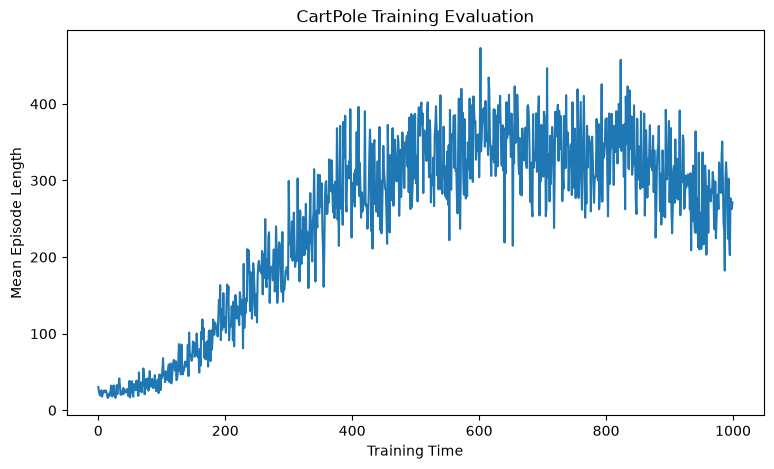

In [13]:
import matplotlib.pyplot as plt

groups = logs.groupby("epoch")
epochs = list(groups.groups.keys())

avg_eps = groups["eplen"].mean().to_list()

plt.figure(figsize=(9, 5))
plt.ylabel("Mean Episode Length")
plt.xlabel("Training Time")
plt.title("CartPole Training Evaluation")
plt.plot(avg_eps)

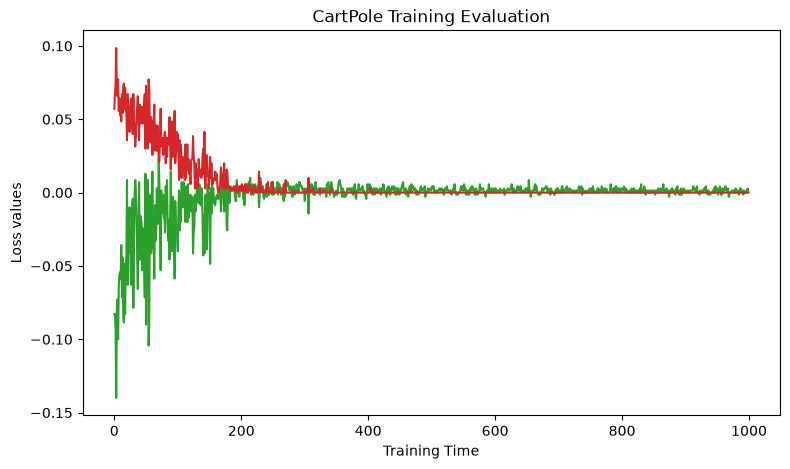

In [14]:
a_losses = groups["aLoss"].mean().to_list()
c_losses = groups["cLoss"].mean().to_list()

plt.figure(figsize=(9, 5))
plt.ylabel("Loss values")
plt.xlabel("Training Time")
plt.title("CartPole Training Evaluation")
plt.plot(epochs, a_losses, label="Actor Loss", color="tab:green")
plt.plot(epochs, c_losses, label="Critic Loss", color="tab:red")

##### Test the trained agent

In [15]:
import torch
import gymnasium as gym
from matplotlib import pyplot as plt
from IPython.display import clear_output

from Ch5_definitions import ActorCritic


def run_test():
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    state, _ = env.reset()

    done = False
    episodes = 0
    while not done:
        pred = torch.from_numpy(state).float()
        logits, value = model(pred)
        action_dist = torch.distributions.Categorical(logits=logits)
        action = action_dist.sample()
        state, reward, terminated, truncated, info = env.step(action.detach().numpy())
        done = terminated or truncated

        frame = env.render()
        clear_output(wait=True)
        plt.imshow(frame)
        plt.title(f"Score: {episodes}")
        plt.axis("off")
        plt.show()
        episodes += 1

    env.close()

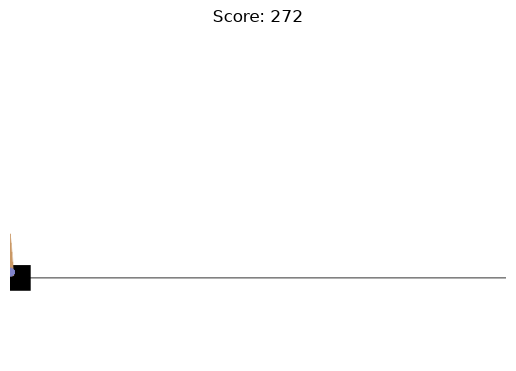

In [16]:
model = ActorCritic()
model.load_state_dict(torch.load("actor_critic_model.pth", weights_only=True))

run_test()

##### Listing 5.9 - N-step training with CartPole

In [17]:
%%writefile -a Ch5_definitions.py

def run_episode_n(worker_env, worker_model, N_steps, eplen_acc):
    state_ = np.array(worker_env.unwrapped.state, dtype=np.float32)
    state = torch.from_numpy(state_).float()
    values, logprobs, rewards = [], [], []
    done = False
    j = 0
    eplen = 0
    while j < N_steps and not done:  # B
        j += 1
        policy, value = worker_model(state)
        values.append(value)
        logits = policy.view(-1)
        action_dist = torch.distributions.Categorical(logits=logits)
        action = action_dist.sample()
        logprob_ = policy.view(-1)[action]
        logprobs.append(logprob_)
        state_, _, terminated, truncated, _ = worker_env.step(action.detach().numpy())
        done = terminated or truncated
        state = torch.from_numpy(state_).float()
        if done:
            reward = -10
            worker_env.reset()
            eplen = eplen_acc
            eplen_acc = 0
        else:  # C
            reward = 1.0
            eplen_acc += 1
        rewards.append(reward)
    
    if done:
        G = torch.Tensor([0.0])  # A
    else:
        G = value.detach()
    return values, logprobs, rewards, G, eplen, eplen_acc


Appending to Ch5_definitions.py


In [18]:
shutil.copy("Ch5_definitions.py", "worker.py")

'worker.py'

In [19]:
%%writefile -a worker.py

if __name__ == "__main__": 
    MasterNode = ActorCritic()  # A
    MasterNode.share_memory()  # B

    params = {"epochs": 2500, "n_workers": 7, "n_steps": 10}
    train_actor_critic(MasterNode, params)

    # Save the trained model weights
    torch.save(MasterNode.state_dict(), "actor_critic_model.pth")


Appending to worker.py


In [20]:
!python worker.py

17440
Process 0 success. 0
Process 1 success. 0
Process 2 success. 0
Process 3 success. 0
Process 4 success. 0
Process 5 success. 0
Process 6 success. 0


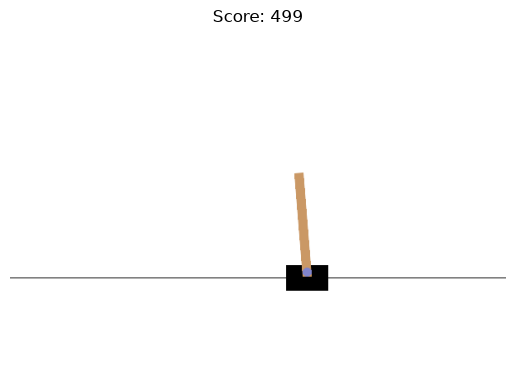

In [21]:
model = ActorCritic()
model.load_state_dict(torch.load("actor_critic_model.pth", weights_only=True))

run_test()

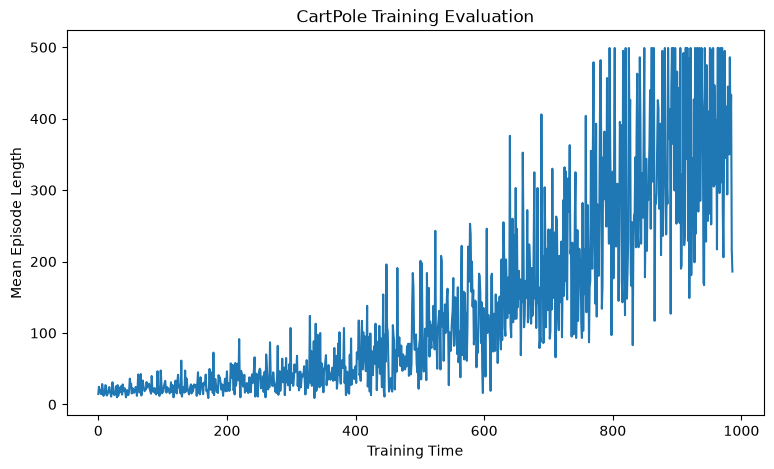

In [22]:
with open("logs.pkl", "rb") as f:
    logs = pd.DataFrame(
        pickle.load(f), columns=["process", "epoch", "eplen", "aLoss", "cLoss"]
    )

groups = logs.groupby("epoch")
epochs = list(groups.groups.keys())

avg_eps = groups["eplen"].mean().to_list()

plt.figure(figsize=(9, 5))
plt.ylabel("Mean Episode Length")
plt.xlabel("Training Time")
plt.title("CartPole Training Evaluation")
plt.plot(avg_eps)

##### Listing 5.10 - Returns with and without bootstrapping

In [23]:
# Simulated rewards for 3 steps
r1 = [1, 1, -1]
r2 = [1, 1, 1]
R1, R2 = 0.0, 0.0
# No bootstrapping
for i in range(len(r1) - 1, 0, -1):
    R1 = r1[i] + 0.99 * R1
for i in range(len(r2) - 1, 0, -1):
    R2 = r2[i] + 0.99 * R2
print("No bootstrapping")
print(R1, R2)
# With bootstrapping
R1, R2 = 1.0, 1.0
for i in range(len(r1) - 1, 0, -1):
    R1 = r1[i] + 0.99 * R1
for i in range(len(r2) - 1, 0, -1):
    R2 = r2[i] + 0.99 * R2
print("With bootstrapping")
print(R1, R2)

No bootstrapping
0.010000000000000009 1.99
With bootstrapping
0.9901 2.9701


In [24]:
import os

os.remove("worker.py")
os.remove("actor_critic_model.pth")
os.remove("logs.pkl")